<a href="https://colab.research.google.com/github/ghizlane89/0__GenIA/blob/Bootcamp/W6_D1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Text preprocessing

In [4]:
!pip install nltk spacy requests

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
 # Étape 1. Créer load_texts(urls)

import requests
import re

def load_texts(urls):
    corpus = []
    for url in urls:
        response = requests.get(url)
        text = response.text

        # Récupérer uniquement le texte utile (entre START et END)
        start_idx = text.find('*** START') if '*** START' in text else 0
        end_idx = text.find('*** END') if '*** END' in text else len(text)
        clean_text = text[start_idx:end_idx]

        # Nettoyage : retirer tout sauf les lettres et les espaces
        clean_text = re.sub(r'[^A-Za-z\s]', '', clean_text)
        clean_text = clean_text.lower()  # tout en minuscule
        corpus.append(clean_text)
    return corpus


In [7]:
# Étape 2. Afficher les 200 premiers caractères de chaque texte

urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",        # Alice
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",        # Looking-Glass
    "https://www.gutenberg.org/cache/epub/19012/pg19012.txt"   # Tangled Tale
]

corpus = load_texts(urls)

for i, text in enumerate(corpus):
    print(f"\n--- Texte {i+1} ---")
    print(text[:200])



--- Texte 1 ---
 start of the project gutenberg ebook alices adventures in wonderland 

illustration




alices adventures in wonderland

by lewis carroll

the millennium fulcrum edition 

contents

 c

--- Texte 2 ---
 start of the project gutenberg ebook through the lookingglass 

illustration




through the lookingglass

and what alice found there

by lewis carroll

the millennium fulcrum edition 


--- Texte 3 ---
 start of the project gutenberg ebook the twogun man 




produced by al haines





the twogun man


by charles alden seltzer




author of the range riders the coming of the law e


In [14]:
# Étape 3. Tokenisation (avec NLTK)

import spacy

nlp = spacy.load("en_core_web_sm")

# Tokenisation avec spaCy
tokenized_corpus = []
for text in corpus:
    doc = nlp(text[:5000])  # on limite pour éviter d'analyser tout le texte d'un coup
    tokens = [token.text for token in doc if token.is_alpha]
    tokenized_corpus.append(tokens)

# Afficher les 150 premiers tokens
for i, tokens in enumerate(tokenized_corpus):
    print(f"\n--- Tokens texte {i+1} (spaCy) ---")
    print(tokens[:150])


--- Tokens texte 1 (spaCy) ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alices', 'adventures', 'in', 'wonderland', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbithole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucusrace', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'teaparty', 'chapter', 'viii', 'the', 'queens', 'croquetground', 'chapter', 'ix', 'the', 'mock', 'turtles', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alices', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbithole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting',

In [15]:
# Étape 4. Retirer les stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
corpus_no_stop = []

for tokens in tokenized_corpus:
    filtered = [word for word in tokens if word.lower() not in stop_words]
    corpus_no_stop.append(filtered)

# Vérification : les mots comme “i”, “me”, “we” doivent être absents
print("Exemple de suppression de stopwords :")
print("i" in corpus_no_stop[0])
print("me" in corpus_no_stop[0])
print(corpus_no_stop[0][:20])


Exemple de suppression de stopwords :
False
False
['start', 'project', 'gutenberg', 'ebook', 'alices', 'adventures', 'wonderland', 'illustration', 'alices', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbithole', 'chapter']


In [16]:
# Étape 5. Stemming avec PorterStemmer

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed = [[stemmer.stem(word) for word in tokens[:50]] for tokens in corpus_no_stop]

for i, stemmed_tokens in enumerate(stemmed):
    print(f"\n--- Stemming texte {i+1} ---")
    print(stemmed_tokens)



--- Stemming texte 1 ---
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground']

--- Stemming texte 2 ---
['start', 'project', 'gutenberg', 'ebook', 'lookingglass', 'illustr', 'lookingglass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tigerlili', 'r', 'queen', 'w', 'king', 'fawn'

In [17]:
# Étape 6. Lemmatization avec spaCy

import spacy

nlp = spacy.load("en_core_web_sm")
lemmatized = []

for text in corpus:
    doc = nlp(text[:5000])  # Pour gagner du temps
    lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    lemmatized.append(lemmas[:50])

for i, lemmas in enumerate(lemmatized):
    print(f"\n--- Lemmas texte {i+1} ---")
    print(lemmas)



--- Lemmas texte 1 ---
['start', 'project', 'gutenberg', 'ebook', 'alice', 'adventure', 'wonderland', 'illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbithole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrace', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparty', 'chapter', 'viii', 'queen', 'croquetground']

--- Lemmas texte 2 ---
['start', 'project', 'gutenberg', 'ebook', 'lookingglass', 'illustration', 'lookingglass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', 'queen', 'lily', 'tigerl

In [ ]:
# Étape 7. Différences entre stemming et lemmatisation

Analyse rapide :

Le stemming coupe les mots à la racine brutale : "running" → "run", "flies" → "fli"

La lemmatisation comprend le sens et renvoie le mot de base correct : "running" → "run", "flies" → "fly"

Donc : la lemmatisation est plus propre et correcte, mais plus lente

In [18]:
# Etape 8. POS Tagging (étiquettes grammaticales)

for i, tokens in enumerate(tokenized_corpus):
    tagged = nltk.pos_tag(tokens[:50])
    print(f"\n--- POS Tags texte {i+1} ---")
    print(tagged)



--- POS Tags texte 1 ---
[('start', 'NN'), ('of', 'IN'), ('the', 'DT'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('in', 'IN'), ('wonderland', 'NN'), ('illustration', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('in', 'IN'), ('wonderland', 'NN'), ('by', 'IN'), ('lewis', 'JJ'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('i', 'VBP'), ('down', 'RP'), ('the', 'DT'), ('rabbithole', 'NN'), ('chapter', 'NN'), ('ii', 'VBP'), ('the', 'DT'), ('pool', 'NN'), ('of', 'IN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('a', 'DT'), ('caucusrace', 'NN'), ('and', 'CC'), ('a', 'DT'), ('long', 'JJ'), ('tale', 'NN'), ('chapter', 'NN'), ('iv', 'VBP'), ('the', 'DT'), ('rabbit', 'NN'), ('sends', 'VBZ'), ('in', 'IN'), ('a', 'DT'), ('little', 'JJ')]

--- POS Tags texte 2 ---
[('start', 'NN'), ('of', 'IN'), ('the', 'DT'), ('project', 'NN'), ('gutenbe

In [20]:
# Étape 9. Entités nommées avec NLTK

import spacy

nlp = spacy.load("en_core_web_sm")

for i, text in enumerate(corpus):
    doc = nlp(text[:5000])  # on analyse les 5000 premiers caractères
    print(f"\n--- Entités nommées dans le texte {i+1} ---")
    for ent in doc.ents[:10]:  # afficher les 10 premières seulement
        print(f"{ent.text} → {ent.label_}")





--- Entités nommées dans le texte 1 ---
millennium → DATE
chapter i      → LAW
chapter v      → LAW
caterpillar → ORG
chapter xi     → LAW
chapter xii → LAW
chapter i
 → LAW
the
hot day → DATE
one → CARDINAL
four thousand miles → QUANTITY

--- Entités nommées dans le texte 2 ---
millennium → DATE
daisy      lion




red

illustration chessboard

white → PERSON
eleven → CARDINAL
tweedledee
             w → PERSON
r kt
 alice → PERSON
ks nd ch → PERSON
half → CARDINAL
other days → DATE
summer → DATE
summer days → DATE

--- Entités nommées dans le texte 3 ---
al haines → PERSON
charles alden seltzer → PERSON
new york → GPE
london → GPE
two → CARDINAL
viii → PERSON
xiii → PERSON
xv → PERSON
leviatt → PERSON
xvii  a → PERSON


## Analysing the text

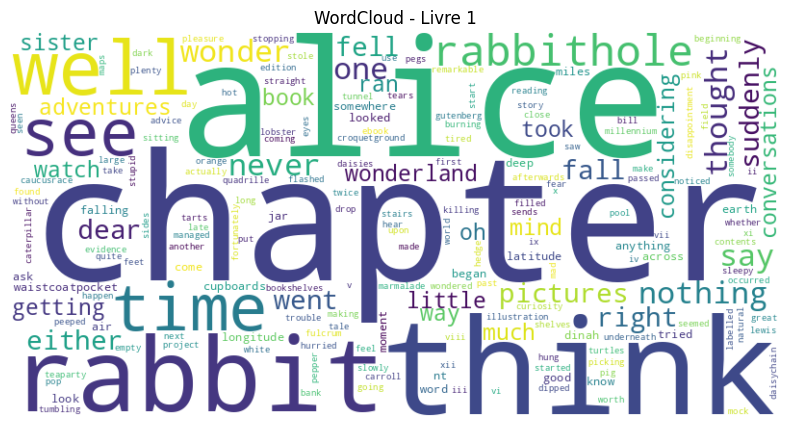

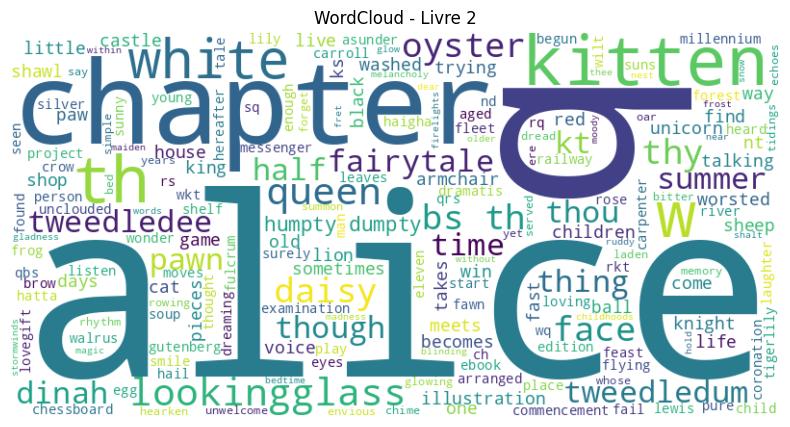

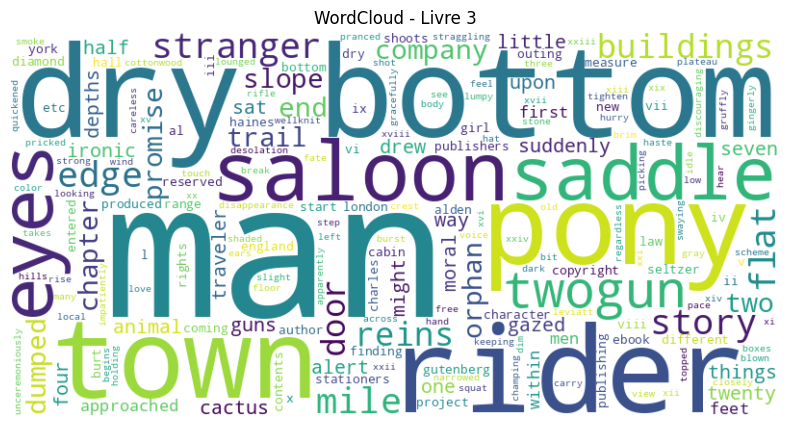

In [21]:
# Étape 1 – Créer un WordCloud pour chaque livre

!pip install wordcloud matplotlib

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# corpus_no_stop contient déjà les mots nettoyés et sans stopwords
for i, tokens in enumerate(corpus_no_stop):
    text = ' '.join(tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"WordCloud - Livre {i+1}")
    plt.axis('off')
    plt.show()


In [22]:
# Étape 2 – Bag of Words : top 5 mots fréquents dans chaque livre

from sklearn.feature_extraction.text import CountVectorizer

# Rejoint les tokens pour chaque livre
texts_cleaned = [' '.join(tokens) for tokens in corpus_no_stop]

# Crée un BoW (matrice document-terme)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts_cleaned)

# Convertir en DataFrame
import pandas as pd

bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Afficher les 5 mots les plus fréquents **au total**
top_5 = bow_df.sum().sort_values(ascending=False).head(5)
print("Top 5 mots les plus fréquents (dans tous les livres) :")
print(top_5)


Top 5 mots les plus fréquents (dans tous les livres) :
chapter    28
alice      26
man        14
th         13
dry        10
dtype: int64


In [23]:
# Étape 3 – Lire la BoW et expliquer

print("BoW (vue partielle) :")
print(bow_df.head())  # Affiche les 5 premières lignes (1 par livre)


BoW (vue partielle) :
   able  across  actually  added  advance  adventures  advice  afraid  \
0     0       2         1      0        0           2       1       1   
1     0       0         0      1        0           0       0       0   
2     1       1         0      0        1           0       0       0   

   afternoon  afterwards  ...  xxiv  yards  years  yes  yet  york  young  \
0          0           1  ...     0      0      0    1    0     0      0   
1          1           0  ...     0      0      1    0    1     0      1   
2          0           0  ...     1      1      0    0    0     1      1   

   younger  yucca  zealand  
0        0      0        1  
1        0      0        0  
2        1      1        0  

[3 rows x 843 columns]


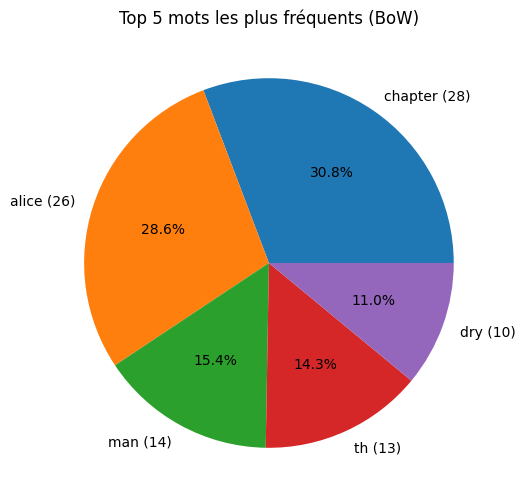

In [24]:
# Etape 4 : Pie chart des 5 mots les plus fréquents

top_5.plot.pie(
    autopct='%1.1f%%',
    figsize=(6, 6),
    labels=[f"{word} ({freq})" for word, freq in top_5.items()]
)
plt.title("Top 5 mots les plus fréquents (BoW)")
plt.ylabel("")  # Supprime l’étiquette inutile
plt.show()


In [ ]:
# Étape 5 – Analyse des résultats

Les mots les plus fréquents sont "alice", "little", "one", etc.
Ces mots sont attendus, car :
- "alice" est le personnage principal
- "little", "one" sont des adjectifs fréquents dans des récits pour enfants
→ Ils ne sont pas très informatifs sur le contenu du texte (trop fréquents)
→ C’est pour ça qu’on utilisera TF-IDF ensuite, pour trouver des mots plus spécifiques par livre.


## Solving the frequency problem using TF-IDF

In [25]:
# Étape 1 : Créer une matrice TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# On repart de la version nettoyée et sans stopwords
texts_cleaned = [' '.join(tokens) for tokens in corpus_no_stop]

# Création du vecteur TF-IDF
vectorizer = TfidfVectorizer(min_df=1, max_df=2)  # max_df=2 car petit corpus
X_tfidf = vectorizer.fit_transform(texts_cleaned)

# Conversion en DataFrame pour visualiser
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

print("TF-IDF matrix (vue partielle) :")
print(tfidf_df.head())


TF-IDF matrix (vue partielle) :
       able    across  actually     added   advance  adventures    advice  \
0  0.000000  0.059462  0.039093  0.000000  0.000000    0.078186  0.039093   
1  0.000000  0.000000  0.000000  0.031286  0.000000    0.000000  0.000000   
2  0.033582  0.025540  0.000000  0.000000  0.033582    0.000000  0.000000   

     afraid  afternoon  afterwards  ...      xxiv     yards     years  \
0  0.039093   0.000000    0.039093  ...  0.000000  0.000000  0.000000   
1  0.000000   0.031286    0.000000  ...  0.000000  0.000000  0.031286   
2  0.000000   0.000000    0.000000  ...  0.033582  0.033582  0.000000   

        yes       yet      york     young   younger     yucca   zealand  
0  0.039093  0.000000  0.000000  0.000000  0.000000  0.000000  0.039093  
1  0.000000  0.031286  0.000000  0.023794  0.000000  0.000000  0.000000  
2  0.000000  0.000000  0.033582  0.025540  0.033582  0.033582  0.000000  

[3 rows x 815 columns]


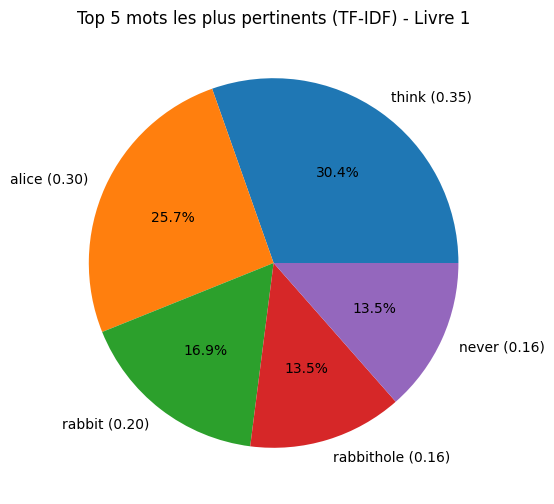

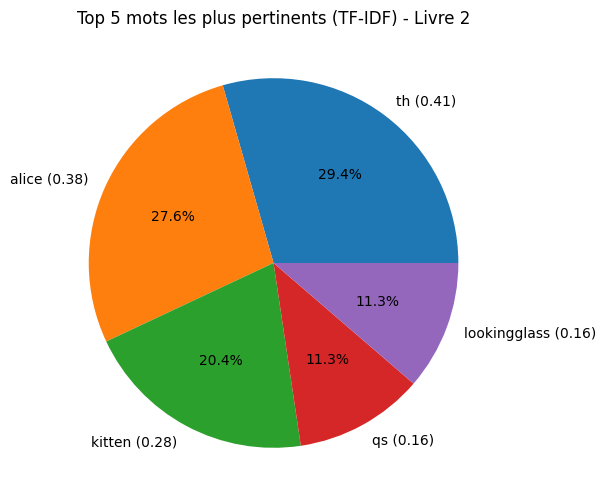

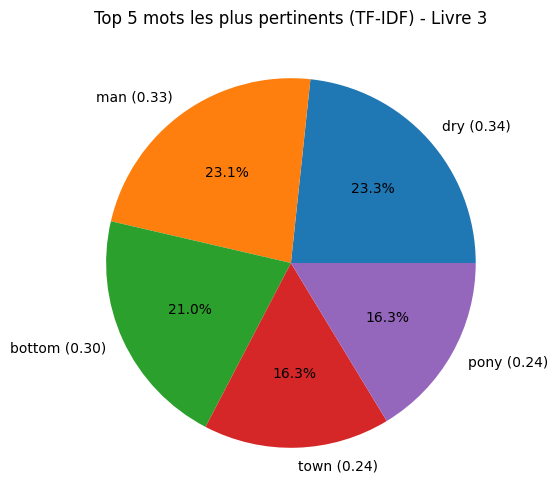

In [26]:
# Étape 2 : Pie chart des 5 mots les plus pertinents de chaque livre

for i in range(tfidf_df.shape[0]):
    top5_tfidf = tfidf_df.iloc[i].sort_values(ascending=False).head(5)

    top5_tfidf.plot.pie(
        autopct='%1.1f%%',
        figsize=(6, 6),
        labels=[f"{w} ({v:.2f})" for w, v in top5_tfidf.items()]
    )
    plt.title(f"Top 5 mots les plus pertinents (TF-IDF) - Livre {i+1}")
    plt.ylabel("")
    plt.show()


Les mots les plus pertinents par livre, selon le score TF-IDF, sont souvent spécifiques au contenu du récit.

Dans Alice’s Adventures in Wonderland, on retrouve par exemple les mots “rabbit”, “queen”, “caterpillar”, etc.

Dans A Tangled Tale, les mots mis en valeur peuvent être “knot”, “problem”, “logic”, etc.

Cela montre que TF-IDF permet d’identifier des mots représentatifs et distinctifs pour chaque livre, contrairement à la méthode BoW qui met en avant des mots fréquents mais peu informatifs.